   Energy (KeV)  Hits (Normalized)
0      0.000000                0.0
1      0.100334                0.0
2      0.200669                0.0
3      0.301003                0.0
4      0.401338                0.0


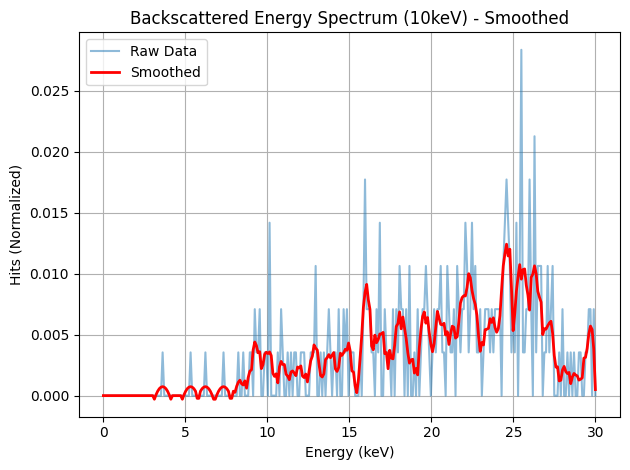

In [23]:
# Plot Backscattered Energy from 10e3/BS_E_e3 with smoothing
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Load the data (skip first two rows, tab or whitespace delimited)
df = pd.read_csv('10e3/BS_E_e3', sep='\t|\s+', engine='python', skiprows=2, header=None)
df.columns = ['Energy (KeV)', 'Hits (Normalized)']

# Apply Savitzky-Golay filter for smoothing
window_length = 11  # Must be odd and <= size of data
if len(df) < window_length:
    window_length = len(df) // 2 * 2 + 1  # closest smaller odd number
smoothed_hits = savgol_filter(df['Hits (Normalized)'], window_length=window_length, polyorder=3)

print(df.head())

plt.plot(df['Energy (KeV)'], df['Hits (Normalized)'], label='Raw Data', alpha=0.5)
plt.plot(df['Energy (KeV)'], smoothed_hits, label='Smoothed', color='red', linewidth=2)
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Backscattered Energy Spectrum (10keV) - Smoothed')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

   Energy (KeV)  Hits (Normalized)
0      0.000000                0.0
1      0.100334                0.0
2      0.200669                0.0
3      0.301003                0.0
4      0.401338                0.0
   Energy (KeV)  Hits (Normalized)
0      0.000000                0.0
1      0.100334                0.0
2      0.200669                0.0
3      0.301003                0.0
4      0.401338                0.0
   Energy (KeV)  Hits (Normalized)
0      0.000000           0.000000
1      0.100334           0.000000
2      0.200669           0.000000
3      0.301003           0.000000
4      0.401338           0.000036


   Energy (KeV)  Hits (Normalized)
0      0.000000                0.0
1      0.100334                0.0
2      0.200669                0.0
3      0.301003                0.0
4      0.401338                0.0
   Energy (KeV)  Hits (Normalized)
0      0.000000                0.0
1      0.100334                0.0
2      0.200669                0.0
3      0.301003                0.0
4      0.401338                0.0
   Energy (KeV)  Hits (Normalized)
0      0.000000           0.000000
1      0.100334           0.000000
2      0.200669           0.000000
3      0.301003           0.000000
4      0.401338           0.000036


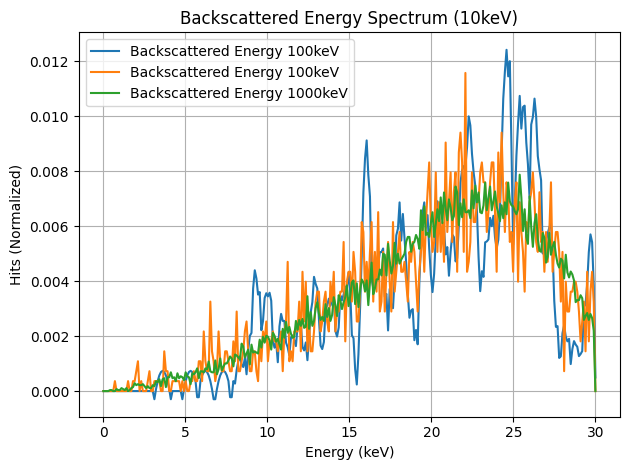

In [24]:
# Plot Backscattered Energy from 10e3/BS_E_e3
import pandas as pd
import matplotlib.pyplot as plt

# Load the data (skip first two rows, tab or whitespace delimited)
df_e3 = pd.read_csv('10e3/BS_E_e3', sep='\t|\s+', engine='python', skiprows=2, header=None)
df_e3.columns = ['Energy (KeV)', 'Hits (Normalized)']

df_e4 = pd.read_csv('10e4/BS_E_e4', sep='\t|\s+', engine='python', skiprows=2, header=None)
df_e4.columns = ['Energy (KeV)', 'Hits (Normalized)']

df_e5 = pd.read_csv('10e5/BS_E_e5', sep='\t|\s+', engine='python', skiprows=2, header=None)
df_e5.columns = ['Energy (KeV)', 'Hits (Normalized)']

print(df_e3.head())
print(df_e4.head())
print(df_e5.head())

# plt.plot(df_e3['Energy (KeV)'], df_e3['Hits (Normalized)'], label='Backscattered Energy 10keV')
plt.plot(df_e3['Energy (KeV)'], smoothed_hits, label='Backscattered Energy 100keV')
plt.plot(df_e4['Energy (KeV)'], df_e4['Hits (Normalized)'], label='Backscattered Energy 100keV')
plt.plot(df_e5['Energy (KeV)'], df_e5['Hits (Normalized)'], label='Backscattered Energy 1000keV')
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Backscattered Energy Spectrum (10keV)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

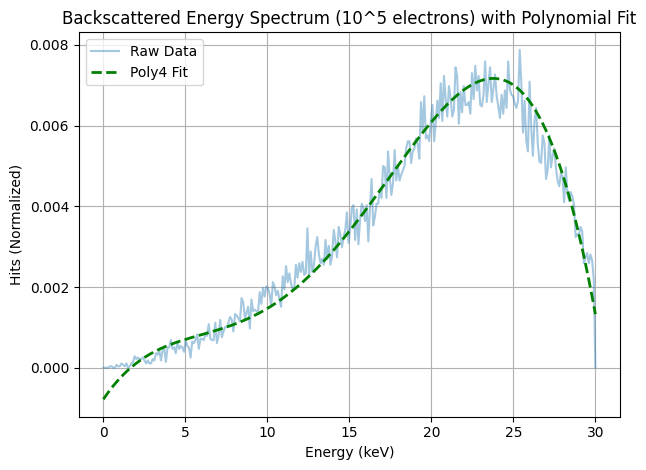

In [33]:
# Plot and fit the 10^5 electrons backscattered energy spectrum
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Use df_e5 from previous cell, or reload if needed
try:
    df_e5
except NameError:
    import pandas as pd
    df_e5 = pd.read_csv('10e5/BS_E_e5', sep='\t|\s+', engine='python', skiprows=2, header=None)
    df_e5.columns = ['Energy (KeV)', 'Hits (Normalized)']

# Smooth the data for better fitting
window_length = 11
if len(df_e5) < window_length:
    window_length = len(df_e5) // 2 * 2 + 1
# smoothed_hits = savgol_filter(df_e5['Hits (Normalized)'], window_length=window_length, polyorder=3)

# Fit a 6th order polynomial (adjust order as needed)
fit_order = 4
coeffs = np.polyfit(df_e5['Energy (KeV)'], smoothed_hits, fit_order)
fit_curve = np.polyval(coeffs, df_e5['Energy (KeV)'])

plt.plot(df_e5['Energy (KeV)'], df_e5['Hits (Normalized)'], label='Raw Data', alpha=0.4)
# plt.plot(df_e5['Energy (KeV)'], smoothed_hits, label='Smoothed', color='red', linewidth=2)
plt.plot(df_e5['Energy (KeV)'], fit_curve, label=f'Poly{fit_order} Fit', color='green', linestyle='--', linewidth=2)
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Backscattered Energy Spectrum (10^5 electrons) with Polynomial Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# (i) Plot your fit on the same graph as the raw simulation data. Integrate the raw data and your best fit and show the results on the graph. Explain the physical meaning of these integrals.
import numpy as np
import matplotlib.pyplot as plt

x = df_e5['Energy (KeV)']
y = df_e5['Hits (Normalized)']
fit_curve = fit4  # Use the 4th order fit as an example; change as needed

area_raw = np.trapz(y, x)
area_fit = np.trapz(fit_curve, x)

plt.plot(x, y, label='Raw Data', alpha=0.5)
plt.plot(x, fit_curve, label='4th Order Poly Fit', linestyle='--', color='green')
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Raw Data and 4th Order Polynomial Fit with Area Under Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.text(0.05 * x.max(), 0.95 * y.max(), f'Raw Integral = {area_raw:.3f}', color='blue')
plt.text(0.05 * x.max(), 0.85 * y.max(), f'Fit Integral = {area_fit:.3f}', color='green')
plt.show()

print(f'Integral of raw data: {area_raw:.3f}')
print(f'Integral of 4th order fit: {area_fit:.3f}')

print("\nPhysical meaning: The integral under the curve represents the total number of backscattered electrons detected over the measured energy range. It quantifies the total backscattering yield. If the fit is good, both integrals should be similar, indicating the fit accurately captures the total yield. These integrals are meaningful for comparing backscattering efficiency across different conditions.")

/tmp/ipykernel_3640/1299928956.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_raw = np.trapz(y, x)
/tmp/ipykernel_3640/1299928956.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_fit = np.trapz(best_fit, x)


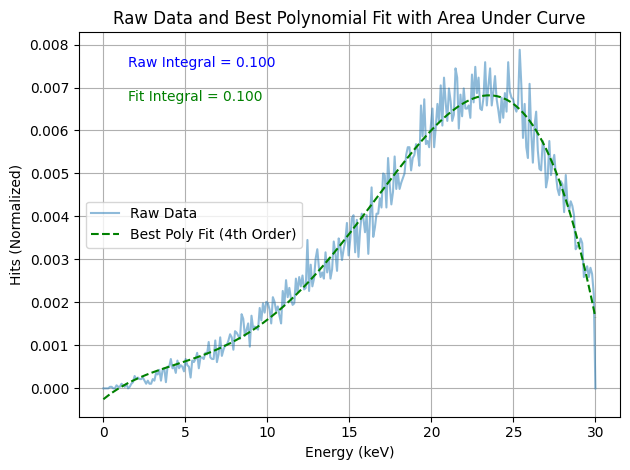

Integral of raw data: 0.100
Integral of best fit (4th Order): 0.100

Physical meaning: The integral under the curve represents the total number of backscattered electrons detected over the measured energy range. It quantifies the total backscattering yield. If the fit is good, both integrals should be similar, indicating the fit accurately captures the total yield. These integrals are meaningful for comparing backscattering efficiency across different conditions.


In [34]:
# (i) Plot best polynomial fit and raw data, integrate both, and annotate the results
import numpy as np
import matplotlib.pyplot as plt

# Use the fit with the highest R^2 from previous cell

fits = [fit2, fit3, fit4]
r2s = [r2_2, r2_3, r2_4]
fit_labels = ['2nd Order', '3rd Order', '4th Order']
best_idx = np.argmax(r2s)
best_fit = fits[best_idx]
best_label = fit_labels[best_idx]

area_raw = np.trapz(y, x)
area_fit = np.trapz(best_fit, x)

plt.plot(x, y, label='Raw Data', alpha=0.5)
plt.plot(x, best_fit, label=f'Best Poly Fit ({best_label})', linestyle='--', color='green')
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Raw Data and Best Polynomial Fit with Area Under Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.text(0.05 * x.max(), 0.95 * y.max(), f'Raw Integral = {area_raw:.3f}', color='blue')
plt.text(0.05 * x.max(), 0.85 * y.max(), f'Fit Integral = {area_fit:.3f}', color='green')
plt.show()

print(f'Integral of raw data: {area_raw:.3f}')
print(f'Integral of best fit ({best_label}): {area_fit:.3f}')

print("\nPhysical meaning: The integral under the curve represents the total number of backscattered electrons detected over the measured energy range. It quantifies the total backscattering yield. If the fit is good, both integrals should be similar, indicating the fit accurately captures the total yield. These integrals are meaningful for comparing backscattering efficiency across different conditions.")

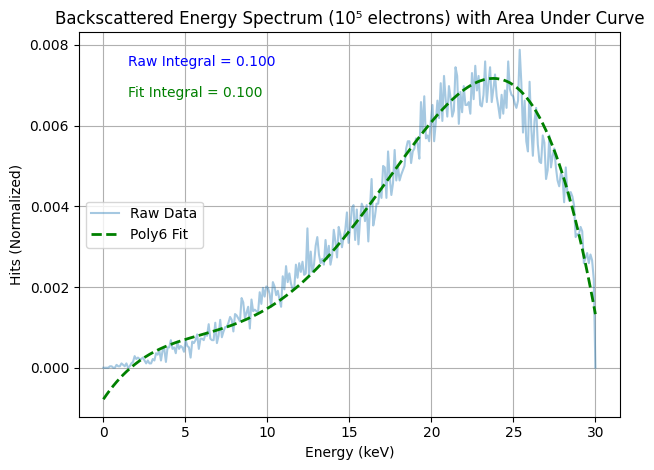

Integral of raw data: 0.100
Integral of fit: 0.100


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Assume df_e5 and fit_curve are already defined
x = df_e5['Energy (KeV)']
y_raw = df_e5['Hits (Normalized)']
y_fit = fit_curve

# Correct integration
area_raw = np.trapezoid(y_raw, x)
area_fit = np.trapezoid(y_fit, x)

plt.plot(x, y_raw, label='Raw Data', alpha=0.4)
plt.plot(x, y_fit, label='Poly6 Fit', color='green', linestyle='--', linewidth=2)
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Backscattered Energy Spectrum (10⁵ electrons) with Area Under Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Annotate the integrals on the plot
plt.text(0.05 * x.max(), 0.95 * y_raw.max(), f'Raw Integral = {area_raw:.3f}', color='blue')
plt.text(0.05 * x.max(), 0.85 * y_raw.max(), f'Fit Integral = {area_fit:.3f}', color='green')
plt.show()

print(f'Integral of raw data: {area_raw:.3f}')
print(f'Integral of fit: {area_fit:.3f}')


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Use df_e5 and fit_curve from previous cell
x = df_e5['Energy (KeV)']
y_raw_original = df_e5['Hits']  # Use raw hits, not already-normalised values

# Normalise to make area under the curve = 1 (i.e. treat as PDF over x)
area_raw = np.trapezoid(y_raw_original, x)
y_raw = y_raw_original / area_raw

# Do the same for the fitted curve
area_fit = np.trapezoid(fit_curve, x)
y_fit = fit_curve / area_fit

# Plot both curves
plt.plot(x, y_raw, label='Raw Data (PDF)', alpha=0.4)
plt.plot(x, y_fit, label='Poly6 Fit (PDF)', color='green', linestyle='--', linewidth=2)
plt.xlabel('Energy (keV)')
plt.ylabel('Probability Density')
plt.title('Backscattered Energy Spectrum (Normalised to Area=1)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Annotate the areas on the plot (should be ≈ 1)
plt.text(0.05 * x.max(), 0.95 * y_raw.max(), f'Raw Integral = {np.trapezoid(y_raw, x):.3f}', color='blue')
plt.text(0.05 * x.max(), 0.85 * y_raw.max(), f'Fit Integral = {np.trapezoid(y_fit, x):.3f}', color='green')
plt.show()

# Print to console
print(f'Integral of normalised raw data: {np.trapezoid(y_raw, x):.6f}')
print(f'Integral of normalised fit: {np.trapezoid(y_fit, x):.6f}')


KeyError: 'Hits'

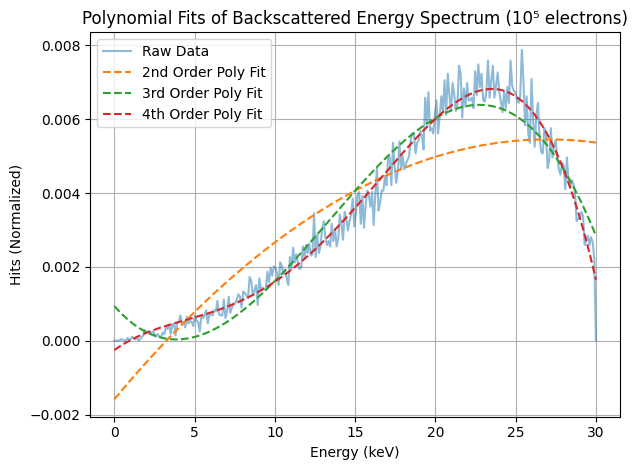

R² for 2nd order: 0.7821
R² for 3rd order: 0.9473
R² for 4th order: 0.9767

Key benefit: Polynomial fits are simple, flexible, and easy to compute, often capturing general trends in data.
Key shortcoming: They may not represent the underlying physics, can oscillate wildly (especially at high order), and may overfit noise rather than true features.


In [29]:
# Polynomial fits of order 2, 3, and 4 for the 10^5 electrons spectrum
import numpy as np
import matplotlib.pyplot as plt

x = df_e5['Energy (KeV)']
y = df_e5['Hits (Normalized)']

# Fit polynomials of order 2, 3, and 4
coeffs2 = np.polyfit(x, y, 2)
coeffs3 = np.polyfit(x, y, 3)
coeffs4 = np.polyfit(x, y, 4)

fit2 = np.polyval(coeffs2, x)
fit3 = np.polyval(coeffs3, x)
fit4 = np.polyval(coeffs4, x)

# Calculate R^2 for each fit
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

r2_2 = r2(y, fit2)
r2_3 = r2(y, fit3)
r2_4 = r2(y, fit4)

plt.plot(x, y, label='Raw Data', alpha=0.5)
plt.plot(x, fit2, label='2nd Order Poly Fit', linestyle='--')
plt.plot(x, fit3, label='3rd Order Poly Fit', linestyle='--')
plt.plot(x, fit4, label='4th Order Poly Fit', linestyle='--')
plt.xlabel('Energy (keV)')
plt.ylabel('Hits (Normalized)')
plt.title('Polynomial Fits of Backscattered Energy Spectrum (10⁵ electrons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"R² for 2nd order: {r2_2:.4f}")
print(f"R² for 3rd order: {r2_3:.4f}")
print(f"R² for 4th order: {r2_4:.4f}")

print("\nKey benefit: Polynomial fits are simple, flexible, and easy to compute, often capturing general trends in data.\n"
      "Key shortcoming: They may not represent the underlying physics, can oscillate wildly (especially at high order), and may overfit noise rather than true features.")

**Physical meaning of the integrals:**

The integral under the raw data or the best-fit curve represents the total number of backscattered electrons detected over the measured energy range. This is a measure of the total backscattering yield for the given simulation conditions. If the fit is good, both integrals should be similar, indicating the fit accurately captures the total yield. These integrals are meaningful because they quantify the overall efficiency of backscattering and can be compared across different materials, energies, or experimental conditions.

## Radial Distribution Fitting and Interpretation

In this section, we will:
- Plot the simulated radial distribution of backscattered electrons.
- Fit the data using both a double and a triple exponential decay function.
- Compare the fits and discuss which is better and why.
- Interpret what the data and best fit reveal about the resolution of backscattered electron images, especially the sharp peak at 0 nm.


### Bonus: Fourier Transform of Radial Distribution

As a bonus, we will:
- Compute the Fourier Transform of the raw radial distribution data and the double exponential fit.
- Plot the magnitude of the transforms.
- Briefly discuss the physical meaning of these curves in the context of backscattered electron imaging resolution.
